# Sea Surface Salinity Algorithms

## Imports

We will use `numpy` for calculations, `pandas` for tabular summaries, and `matplotlib` for simple plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,
})

# Part 3: SSS Algorithms

## Developing an SSS algorithm

A satellite SSS algorithm begins with measured brightness temperature and removes or corrects for non-salinity contributions. These corrections are needed before converting emissivity into salinity.

Major correction terms include:

1. **Sea surface temperature**, because emission depends on physical temperature.
2. **Surface roughness and foam**, which alter emissivity.
3. **Atmospheric oxygen, water vapor, and clouds**, which absorb and emit microwave radiation.
4. **Solar microwave emission**, which can reflect off the ocean surface.
5. **Ionospheric Faraday rotation**, which changes polarization.
6. **Galactic and cosmic microwave background radiation**, which can be reflected or received by the sensor.
7. **Land and sea ice contamination**, especially near coasts and ice edges.

## Conceptual algorithm workflow

A simplified satellite SSS retrieval can be written as:

\[
T_B^{corrected} = T_B^{observed} - T_B^{atm} - T_B^{space} - T_B^{ionosphere} - T_B^{other}
\]

Then, an emissivity model is used to find the salinity that best explains the corrected brightness temperature:

\[
S = f^{-1}(T_B^{corrected}, T_S, f, \theta, p, \text{roughness})
\]

In real retrieval algorithms, this inversion is performed using detailed geophysical model functions and laboratory-calibrated dielectric models of seawater.

In [10]:
# Conceptual correction example
terms = pd.DataFrame({
    'Term': [
        'Observed brightness temperature',
        'Atmospheric oxygen correction',
        'Water vapor/cloud correction',
        'Surface roughness correction',
        'Solar/galactic reflection correction',
        'Ionospheric correction'
    ],
    'Example Magnitude or Role': [
        'Measured by the satellite radiometer',
        'O2 contributes roughly several K at L-band',
        'Smaller but non-negligible',
        'Can be large under windy conditions',
        'Depends on geometry and background source strength',
        'Corrects polarization rotation'
    ],
    'Why It Matters': [
        'Starting point for retrieval',
        'Atmosphere also emits microwaves',
        'Clouds and vapor affect microwave propagation',
        'Roughness changes ocean emissivity',
        'Non-ocean radiation can enter the sensor',
        'SSS retrieval depends on polarization'
    ]
})
terms

,Term,Example Magnitude or Role,Why It Matters
0,Observed brightness temperature,Measured by the satellite radiometer,Starting point for retrieval
1,Atmospheric oxygen correction,O2 contributes roughly several K at L-band,Atmosphere also emits microwaves
2,Water vapor/cloud correction,Smaller but non-negligible,Clouds and vapor affect microwave propagation
3,Surface roughness correction,Can be large under windy conditions,Roughness changes ocean emissivity
4,Solar/galactic reflection correction,Depends on geometry and background source stre...,Non-ocean radiation can enter the sensor
5,Ionospheric correction,Corrects polarization rotation,SSS retrieval depends on polarization


## Surface roughness and foam

In the L-band, sea surface roughness and foam strongly influence emissivity. Retrieval algorithms use **geophysical model functions** to correct for roughness before estimating salinity.

Roughness is closely related to wind speed, so satellite SSS retrievals often use coincident wind information. This is one reason why multi-sensor observations and auxiliary environmental data are important for SSS products.

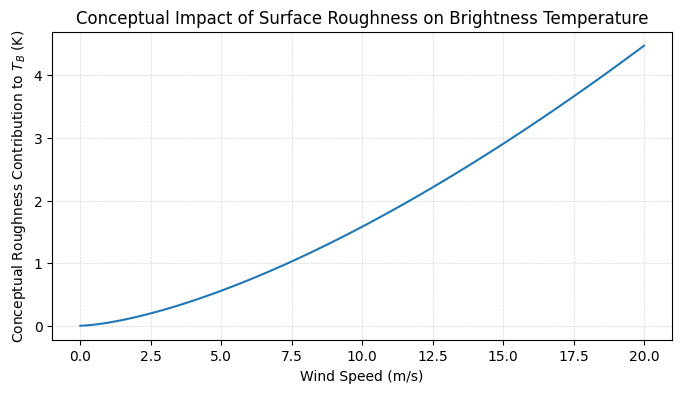

In [11]:
# Conceptual effect of wind speed on observed brightness temperature
wind = np.linspace(0, 20, 100)  # m/s
roughness_effect = 0.05 * wind**1.5  # conceptual only, K

plt.plot(wind, roughness_effect)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Conceptual Roughness Contribution to $T_B$ (K)')
plt.title('Conceptual Impact of Surface Roughness on Brightness Temperature')
plt.show()

## Atmospheric oxygen

Atmospheric oxygen absorbs and emits microwave radiation. At L-band, oxygen contributes roughly several kelvin to the measured brightness temperature. This is large compared with the small salinity-driven signal, so atmospheric models are used to remove this effect.

Water vapor and clouds also contribute, although generally less strongly than oxygen at L-band.

## Solar, galactic, and cosmic microwave signals

The ocean surface can reflect microwave radiation from the Sun, the cosmic microwave background, and the galaxy. Aquarius was designed with an orbit geometry that reduced reflected solar L-band radiation reaching the sensor.

The cosmic microwave background is approximately 2.75 K, while the galactic contribution varies spatially and must be modeled. Remaining biases from background radiation can still affect global SSS products.

## Ionospheric Faraday rotation

SSS retrievals depend on polarization. As microwave radiation travels through the ionosphere, its polarization can rotate through a process called **Faraday rotation**. Models of total electron content in the ionosphere are used to correct this effect.

## Land and sea ice contamination

Microwave emission from land and sea ice can contaminate the ocean signal. This is especially important near coastlines and ice edges. Many SSS products mask these regions to avoid misinterpretation.

This means satellite SSS is often less reliable or unavailable in:

- narrow coastal zones,
- high-latitude regions near sea ice,
- regions with strong rainfall or near-surface stratification,
- areas with strong radio-frequency interference.

## Validation with observations

Satellite SSS products are validated using independent observations such as:

- Argo floats,
- ship-based thermosalinographs,
- moored buoys,
- surface drifters,
- marine mammal tags.

Validation is challenging because the satellite samples the top few millimeters, while many in situ platforms sample deeper water.

## Summary

Satellite SSS retrieval is a powerful but challenging application of microwave remote sensing.

Key ideas:

- Salinity changes the dielectric properties and emissivity of seawater.
- L-band microwave emission near 1.413 GHz is especially useful for SSS retrievals.
- Brightness temperature depends on salinity, temperature, roughness, polarization, and viewing geometry.
- The SSS signal is small, so algorithms require careful correction for atmosphere, surface roughness, ionosphere, solar/galactic radiation, and land/ice contamination.
- Major satellite SSS missions include SMOS, Aquarius, and SMAP.
- Higher-level products are convenient but should be interpreted cautiously where data are gap-filled or masked.

## Final Check Your Understanding

1. Why does adding salt to water change its microwave emission?
2. Why is the L-band useful for satellite SSS retrievals?
3. Why are SSS retrievals more difficult in cold polar waters?
4. Why are SSS products often masked near coasts and sea ice?
5. What is the difference between a Level 2 SSS product and a Level 4 SSS product?